In [1]:
# conda activate celltyping
import celltyping as ct
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
adata = sc.read_h5ad("/mnt/scratch2/Chloe/Biohackathon/Dataset_5/dataset5.h5ad")

In [3]:
ct.annotate(adata, tissue="skin",
            species="human",                    # or "mouse"
            min_counts=20,                      # QC threshold (transcripts per cell)
            knn_smooth=15,                      # neighbours for expression smoothing; None disables
            method="hierarchical",              # or "flat" / "cluster"
            min_score=0.5, min_margin=0.25,     # stricter -> more 'unassigned' / coarser labels
            knowledge_kwargs={"census_disease": "any", "min_markers": 5})

19:07:34 INFO celltyping: X looks like raw counts -> preprocessing on
19:07:34 INFO celltyping: QC: 8240 / 9960 cells high quality (1720 flagged low quality: low_counts=1720)
/mnt/scratch1/miniconda3/envs/celltyping_MM/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
19:08:04 INFO celltyping: kNN-smoothed expression (k=15, 8240 high-quality cells) stored in layers['knn_smooth']
19:08:04 WARNING celltyping: ambiguous tissue 'skin'; using UBERON:0000014 (zone of skin). Other candidates: UBERON:0001003 (skin epidermis), UBERON:0002097 (skin of body), UBERON:0002199 (integument)
19:08:04 INFO celltyping: knowledge: loading cached tree for zone of skin (zone_of_skin_fa73a7202337_tree.json)
19:08:05 INFO celltyping: tree: 19 cell types (19 with panel markers), 15 leaves
19:08:05 INFO celltyping: node cell                                     cells=   8240 -> descended   88.2% into 8 children
19:08:05 INFO cellty

AnnData object with n_obs × n_vars = 9960 × 100
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'n_genes_by_counts', 'qc_pass', 'qc_flag', 'hier_level1', 'hier_level2', 'hier_level3', 'hier_level4', 'hier_id', 'hier_label', 'hier_depth', 'hier_score', 'hier_margin'
    var: 'gene_ids', 'feature_types', 'genome', 'original_symbol'
    uns: 'spatialdata_attrs', 'qc', 'log1p', 'normalized', 'knn_smooth', 'hier_params', 'celltyping'
    obsm: 'spatial', 'X_pca', 'hier_scores'
    layers: 'counts', 'knn_smooth'

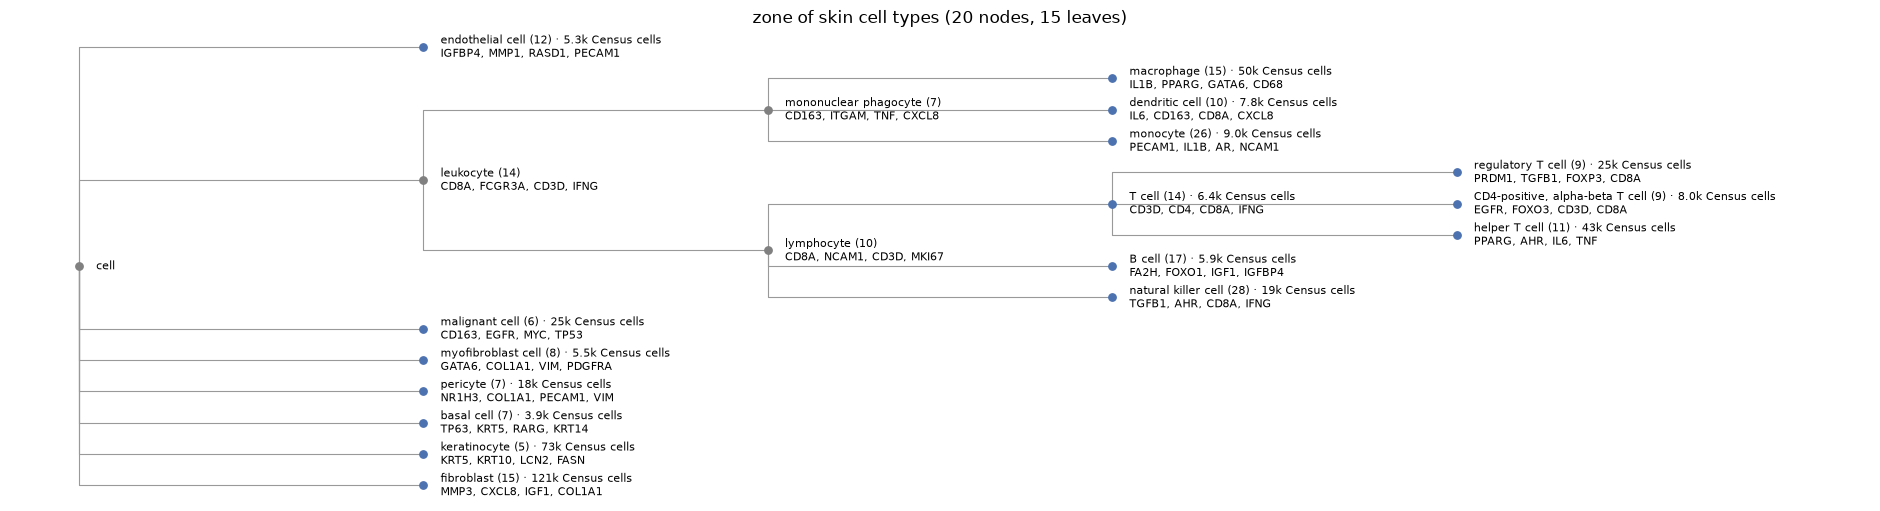

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
tree = ct.tl.get_tree(adata)              # the tree used for this run
ct.pl.tree(tree)                          # hierarchy with panel-marker counts, Census cell counts, top markers
plt.show()

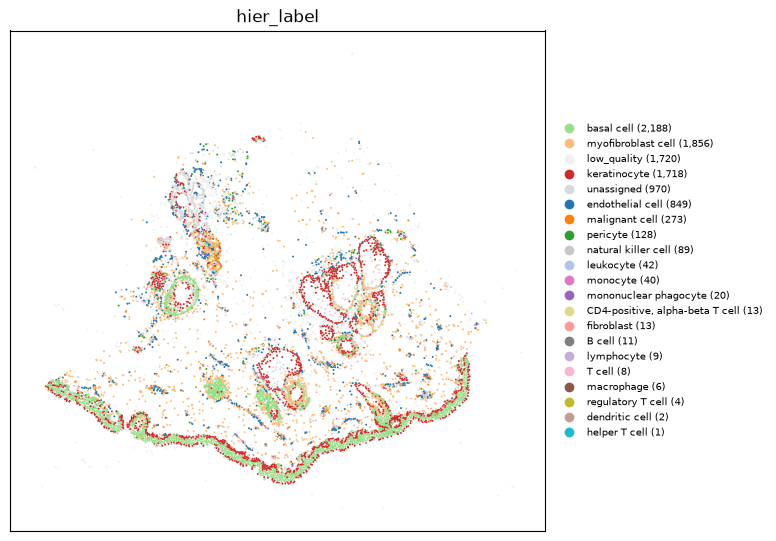

In [5]:
ct.pl.spatial(adata, "hier_label", tree=tree, size = 2)  # confidence (numeric obs columns are supported)
plt.show()

<Axes: xlabel='fraction of cells'>

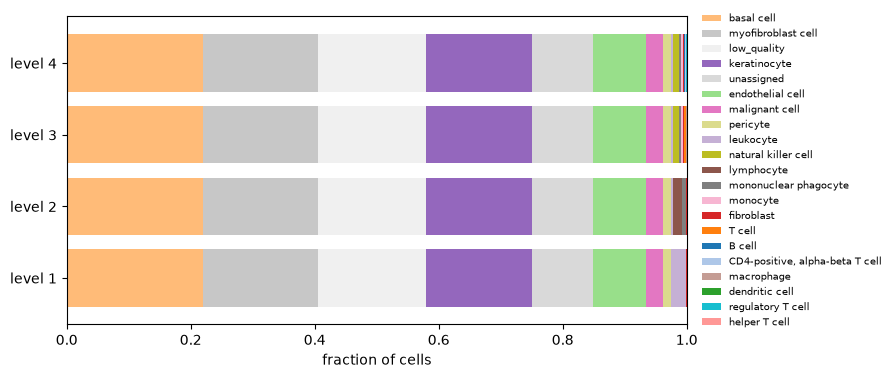

In [9]:
ct.pl.composition(adata)   

<Axes: xlabel='signature', ylabel='hier_label'>

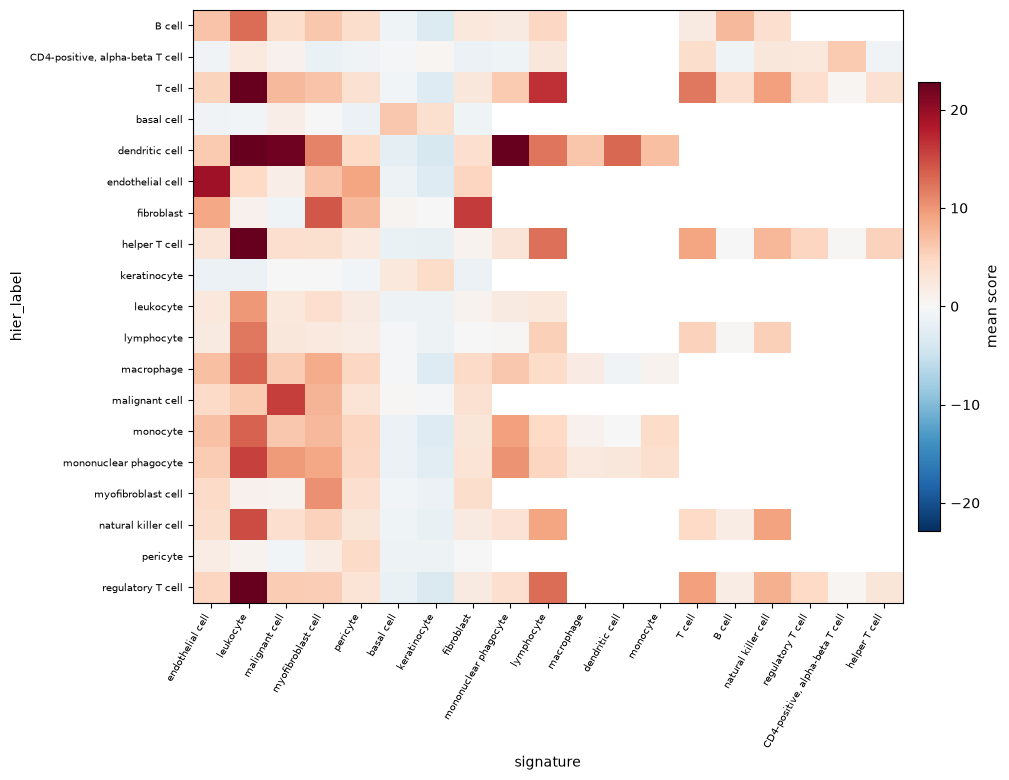

In [6]:
ct.pl.scores(adata, tree=tree)            # mean signature score per predicted label x cell type

In [ ]:
%matplotlib inline

ct.pl.markers(adata, tree)                # scanpy dot-plot of each type's top markers


<Axes: title={'center': 'hier_score'}>

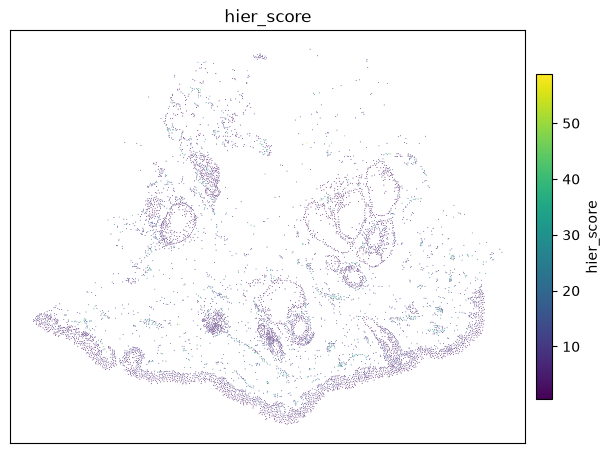

In [17]:
ct.pl.spatial(adata, "hier_score")        # confidence (numeric obs columns are supported)